In [1]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1)	Abrir as imagens coloridas e mostrar a imagem e seus histogramas (separados) cada canal de cor. Considerar os seguintes sistemas de cores:
a.	RGB
b.	HSV ou HSI
c.	Lab


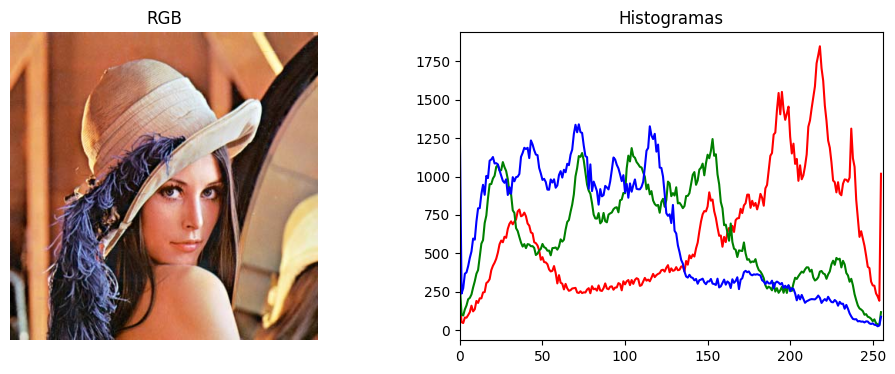

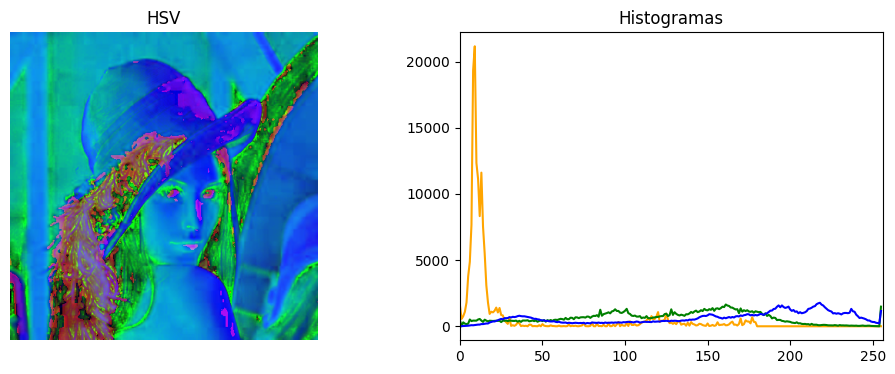

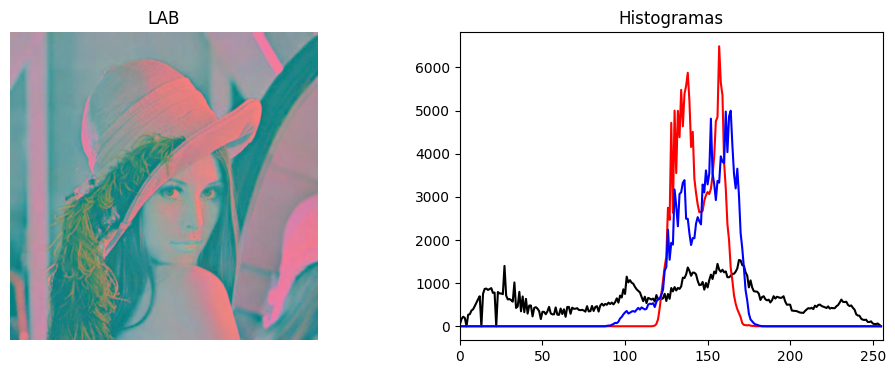

In [2]:
def mostrar_histograma(img, titulo, canais, cores):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(titulo)
    plt.axis("off")

    plt.subplot(1,2,2)

    for i,col in enumerate(cores):
        hist = cv2.calcHist([img],[i],None,[256],[0,256])
        plt.plot(hist,color=col)

    plt.title("Histogramas")
    plt.xlim([0,256])

    plt.show()


img = cv2.imread("Lenna.jpg")
imgRGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

mostrar_histograma(
    imgRGB,
    "RGB",
    ['R','G','B'],
    ['red','green','blue']
)


imgHSV = cv2.cvtColor(imgRGB,cv2.COLOR_RGB2HSV)

mostrar_histograma(
    imgHSV,
    "HSV",
    ['H','S','V'],
    ['orange','green','blue']
)



imgLAB = cv2.cvtColor(imgRGB,cv2.COLOR_RGB2LAB)

mostrar_histograma(
    imgLAB,
    "LAB",
    ['L','a','b'],
    ['black','red','blue']
)

2)	Utilizando a imagem do mandrill, faça rotinas para detecção do focinho (região vermelha e azul). Utilize algum algoritmo de limiarização.

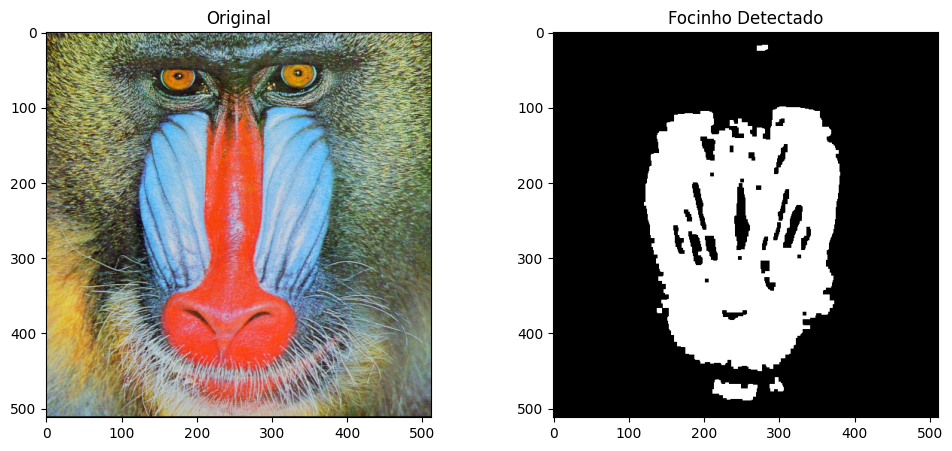

In [4]:
img = cv2.imread("mandrill.tiff")
imgRGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(imgRGB,cv2.COLOR_RGB2HSV)

lower_red1 = np.array([0,80,80])
upper_red1 = np.array([10,255,255])

lower_red2 = np.array([170,80,80])
upper_red2 = np.array([180,255,255])

mask1 = cv2.inRange(hsv,lower_red1,upper_red1)
mask2 = cv2.inRange(hsv,lower_red2,upper_red2)

mask_red = mask1 + mask2


lower_blue = np.array([90,50,50])
upper_blue = np.array([140,255,255])

mask_blue = cv2.inRange(hsv,lower_blue,upper_blue)



mask = cv2.bitwise_or(mask_red,mask_blue)


kernel = np.ones((5,5),np.uint8)

mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN,kernel)
mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,kernel)



plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(imgRGB)
plt.title("Original")

plt.subplot(122)
plt.imshow(mask,cmap='gray')
plt.title("Focinho Detectado")

plt.show()

3)	Utilizando a imagem HE.jpg, tente detectar e contar a quantidade de núcleos celulares (em azul). Aplicar o Ostu para os 9 canais de cores e avaliar qual foi melhor (R,G,B,H,S,V,L,a,b)

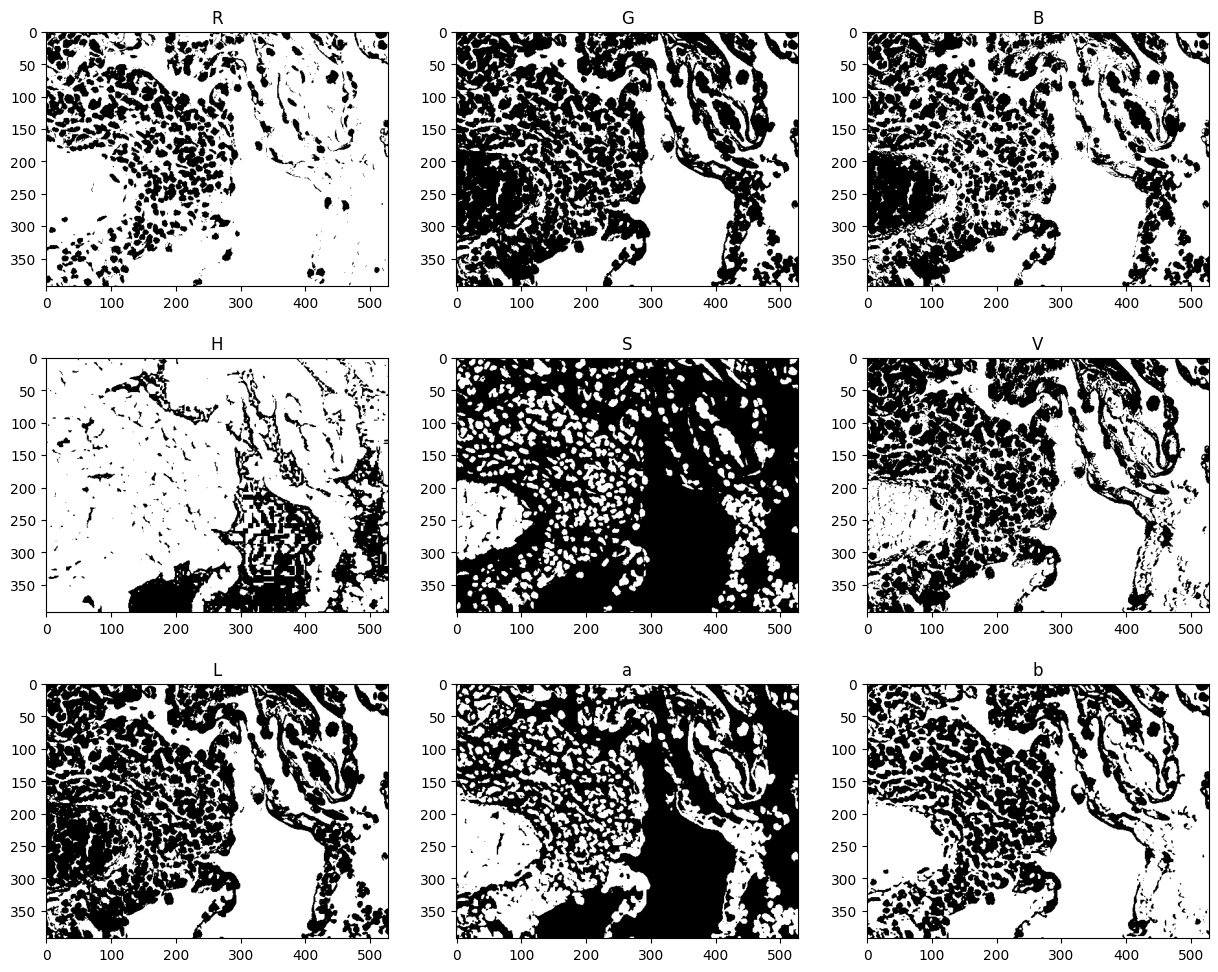

Quantidade de núcleos: 261


In [5]:

img = cv2.imread("HE.jpg")
imgRGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

HSV = cv2.cvtColor(imgRGB,cv2.COLOR_RGB2HSV)
LAB = cv2.cvtColor(imgRGB,cv2.COLOR_RGB2LAB)




canais = {
    "R": imgRGB[:,:,0],
    "G": imgRGB[:,:,1],
    "B": imgRGB[:,:,2],

    "H": HSV[:,:,0],
    "S": HSV[:,:,1],
    "V": HSV[:,:,2],

    "L": LAB[:,:,0],
    "a": LAB[:,:,1],
    "b": LAB[:,:,2]
}


plt.figure(figsize=(15,12))

i=1

for nome,canal in canais.items():

    _,th = cv2.threshold(
        canal,
        0,
        255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU
    )

    plt.subplot(3,3,i)
    plt.imshow(th,cmap='gray')
    plt.title(nome)

    i+=1

plt.show()


melhor = canais["B"]     

_,th = cv2.threshold(
    melhor,
    0,
    255,
    cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU
)


kernel = np.ones((3,3),np.uint8)

th = cv2.morphologyEx(th,cv2.MORPH_OPEN,kernel)

num_labels, labels = cv2.connectedComponents(th)

print("Quantidade de núcleos:", num_labels-1)